# Support Vector Machine Classifer

This notebook will explore the use of SVM to predict hyper- and hypothyroid conditions.

## Import Packages

In [11]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, recall_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

## Read-In Data

In [2]:
X_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')
y_train = np.array(pd.read_csv('train_labels.csv')).reshape(7333,)
y_test = np.array(pd.read_csv('test_labels.csv')).reshape(1834,)

## Scale Data

In [3]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

## Run SVM

In [4]:
def score(y_true, y_pred):
    return np.array(recall_score(y_true, y_pred, average=None)).min()

### No Imblance Fix

#### Linear

##### Find Optimal C

In [9]:
c_vals = np.logspace(-2, 2, 100)
scores = []
for c in c_vals:
    svc_linear = SVC(random_state=6740, kernel='linear', C=c)
    scores.append(cross_val_score(svc_linear, X_train_scaled, y_train, cv=5, scoring=make_scorer(score)).mean())

In [10]:
scores = np.array(scores)
best_c = c_vals[np.where(scores == scores.max())[0][0]]
best_n_recall = scores[np.where(scores == scores.max())[0][0]]
print(f'The best C value is {best_c:.2f} with a recall of {best_n_recall:.4f}') 

The best C value is 3.20 with a recall of 0.4589


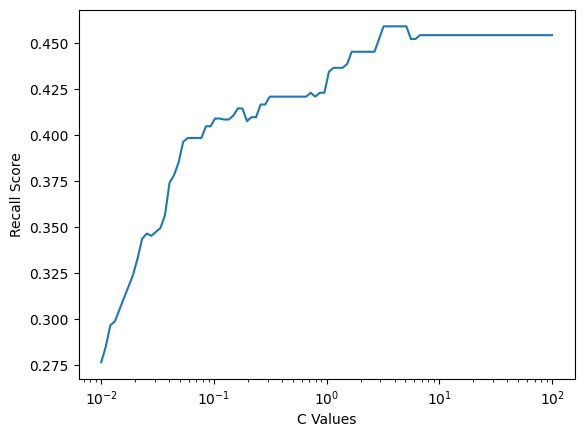

In [11]:
plt.plot(c_vals, scores)
plt.xscale('log')
plt.xlabel('C Values')
plt.ylabel('Recall Score')
plt.show()

##### Use Optimal C

In [14]:
svc_linear = SVC(random_state=6740, kernel='linear', C=best_c)
svc_linear.fit(X_train_scaled, y_train)
y_pred_linear = svc_linear.predict(X_test_scaled)
print(classification_report(y_test, y_pred_linear))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1679
           1       0.83      0.46      0.59       119
           2       0.80      0.44      0.57        36

    accuracy                           0.95      1834
   macro avg       0.86      0.63      0.71      1834
weighted avg       0.94      0.95      0.94      1834



#### Kernelized

##### Find Optimal C and Gamma

In [ ]:
c_vals = np.logspace(1, 5, 10)
gamma_vals = np.logspace(-3, -1, 10)
param_grid = {'C': c_vals, 'gamma': gamma_vals}
svc_rbf = SVC(random_state=6740, kernel='rbf')
clf = GridSearchCV(svc_rbf, param_grid, cv=5, scoring=make_scorer(score))
clf.fit(X_train_scaled, y_train)
print(f'The best C value is {clf.best_params_["C"]:.2f} and the best gamma value is {clf.best_params_["gamma"]:.2f} with a recall of {clf.best_score_:.4f}')

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=6740)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+05]), 'gamma': array([0.001 ..., 0.1 ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(s...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

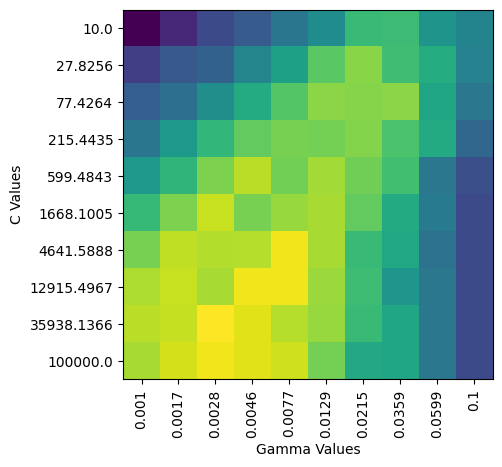

In [57]:
plt.imshow(clf.cv_results_['mean_test_score'].reshape(len(gamma_vals), len(c_vals)))
plt.xticks(np.arange(len(gamma_vals)), gamma_vals.round(4), rotation=90)
plt.xlabel('Gamma Values')
plt.yticks(np.arange(len(c_vals)), c_vals.round(4))
plt.ylabel('C Values')
plt.show()

##### Use Optimal C and Gamma

In [60]:
y_pred_rbf = clf.best_estimator_.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1679
           1       0.89      0.77      0.83       119
           2       0.59      0.56      0.57        36

    accuracy                           0.96      1834
   macro avg       0.82      0.77      0.79      1834
weighted avg       0.96      0.96      0.96      1834



### With SMOTEENN

This package uses SMOTE and ENN together to balance data

In [5]:
smoteenn = SMOTEENN(random_state=6740)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train_scaled, y_train)

#### Linear

##### Find Optimal C

In [ ]:
c_vals = np.logspace(0, 3, 5)
scores = []
for c in c_vals:
    svc_linear_smoteenn = SVC(random_state=6740, kernel='linear', C=c)
    scores.append(cross_val_score(svc_linear_smoteenn, X_train_smoteenn, y_train_smoteenn, cv=5, scoring=make_scorer(score)).mean())

In [ ]:
scores = np.array(scores)
best_c = c_vals[np.where(scores == scores.max())[0][0]]
best_n_recall = scores[np.where(scores == scores.max())[0][0]]
print(f'The best C value is {best_c:.2f} with a recall of {best_n_recall:.4f}') 

The best C value is 100.00 with a recall of 0.9605


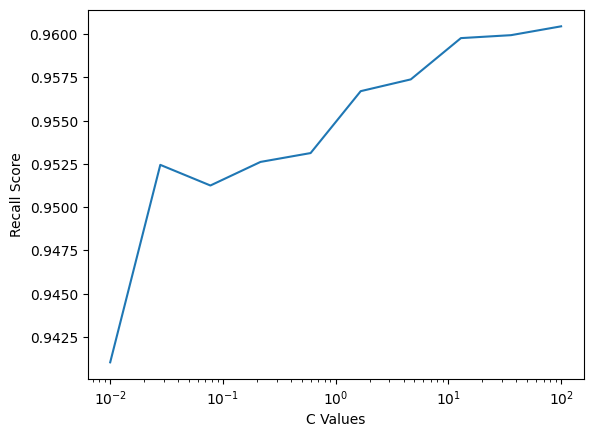

In [ ]:
plt.plot(c_vals, scores)
plt.xscale('log')
plt.xlabel('C Values')
plt.ylabel('Recall Score')
plt.show()

##### Use Optimal C

In [9]:
svc_linear_smoteenn = SVC(random_state=6740, kernel='linear', C=1)
svc_linear_smoteenn.fit(X_train_smoteenn, y_train_smoteenn)
y_pred_linear_smoteenn = svc_linear_smoteenn.predict(X_test_scaled)
print(classification_report(y_test, y_pred_linear_smoteenn))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1679
           1       0.62      0.95      0.75       119
           2       0.37      0.86      0.52        36

    accuracy                           0.93      1834
   macro avg       0.66      0.91      0.74      1834
weighted avg       0.96      0.93      0.94      1834



#### Kernelized

##### Find Optimal C and Gamma

In [6]:
c_vals = np.logspace(-1, 2, 5)
gamma_vals = np.logspace(-1, 2, 5)
param_grid = {'C': c_vals, 'gamma': gamma_vals}
svc_rbf_smoteenn = SVC(random_state=6740, kernel='rbf')
clf = GridSearchCV(svc_rbf_smoteenn, param_grid, cv=5, scoring=make_scorer(score))
clf.fit(X_train_smoteenn, y_train_smoteenn)
print(f'The best C value is {clf.best_params_["C"]:.2f} and the best gamma value is {clf.best_params_["gamma"]:.2f} with a recall of {clf.best_score_:.4f}')

KeyboardInterrupt: 

In [ ]:
plt.imshow(clf.cv_results_['mean_test_score'].reshape(len(gamma_vals), len(c_vals)))
plt.xticks(np.arange(len(gamma_vals)), gamma_vals.round(4), rotation=90)
plt.xlabel('Gamma Values')
plt.yticks(np.arange(len(c_vals)), c_vals.round(4))
plt.ylabel('C Values')
plt.show()

##### Use Optimal C and Gamma

In [ ]:
y_pred_rbf_smoteenn = clf.best_estimator_.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rbf_smoteenn))

In [32]:
svc_rbf_smoteenn = SVC(random_state=6740, kernel='rbf', C=1, gamma=0.1)
svc_rbf_smoteenn.fit(X_train_smoteenn, y_train_smoteenn)
y_pred_rbf_smoteenn = svc_rbf_smoteenn.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rbf_smoteenn))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1679
           1       0.53      0.80      0.64       119
           2       0.61      0.78      0.68        36

    accuracy                           0.93      1834
   macro avg       0.71      0.84      0.76      1834
weighted avg       0.94      0.93      0.93      1834



In [12]:
smote = SMOTE(random_state=6740)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [22]:
svc_rbf_smote = SVC(random_state=6740, kernel='rbf', C=10, gamma=0.01)
svc_rbf_smote.fit(X_train_smote, y_train_smote)
y_pred_rbf_smote = svc_rbf_smote.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rbf_smote))
svc_rbf_smote.n_iter_

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1679
           1       0.70      0.86      0.77       119
           2       0.55      0.83      0.66        36

    accuracy                           0.95      1834
   macro avg       0.74      0.88      0.80      1834
weighted avg       0.96      0.95      0.95      1834



array([4202, 3028,  474], dtype=int32)

In [27]:
svc_rbf_smote = SVC(random_state=6740, kernel='rbf', C=1, gamma=0.1)
svc_rbf_smote.fit(X_train_smote, y_train_smote)
y_pred_rbf_smote = svc_rbf_smote.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rbf_smote))
svc_rbf_smote.n_iter_

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1679
           1       0.67      0.81      0.73       119
           2       0.64      0.78      0.70        36

    accuracy                           0.95      1834
   macro avg       0.76      0.85      0.80      1834
weighted avg       0.95      0.95      0.95      1834



array([4065, 2919, 1472], dtype=int32)

In [16]:
c_vals = np.logspace(-1, 1, 5)
gamma_vals = np.logspace(-2, 0, 5)
param_grid = {'C': c_vals, 'gamma': gamma_vals}
svc_rbf_smote = SVC(random_state=6740, kernel='rbf', max_iter=10000)
clf = GridSearchCV(svc_rbf_smote, param_grid, cv=5, scoring=make_scorer(score))
clf.fit(X_train_smote, y_train_smote)
print(f'The best C value is {clf.best_params_["C"]:.2f} and the best gamma value is {clf.best_params_["gamma"]:.2f} with a recall of {clf.best_score_:.4f}')

d:\Programs\Python3.13\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
d:\Programs\Python3.13\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
d:\Programs\Python3.13\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
d:\Programs\Python3.13\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
d:\Programs\Python3.13\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).

The best C value is 10.00 and the best gamma value is 1.00 with a recall of 0.9853


d:\Programs\Python3.13\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


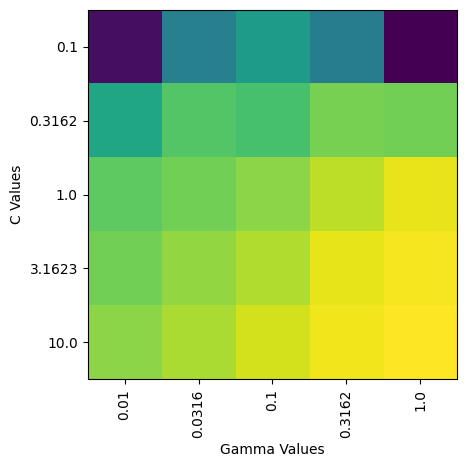

In [17]:
plt.imshow(clf.cv_results_['mean_test_score'].reshape(len(gamma_vals), len(c_vals)))
plt.xticks(np.arange(len(gamma_vals)), gamma_vals.round(4), rotation=90)
plt.xlabel('Gamma Values')
plt.yticks(np.arange(len(c_vals)), c_vals.round(4))
plt.ylabel('C Values')
plt.show()

In [18]:
y_pred_rbf_smote = clf.best_estimator_.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rbf_smote))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1679
           1       0.78      0.44      0.56       119
           2       0.67      0.33      0.44        36

    accuracy                           0.94      1834
   macro avg       0.80      0.59      0.66      1834
weighted avg       0.93      0.94      0.93      1834



In [19]:
clf.best_estimator_.n_iter_

array([10000, 10000, 10000], dtype=int32)

In [20]:
svc_rbf_smote = SVC(random_state=6740, kernel='rbf', C=10, gamma=1)
svc_rbf_smote.fit(X_train_smote, y_train_smote)
y_pred_rbf_smote = svc_rbf_smote.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rbf_smote))
svc_rbf_smote.n_iter_

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1679
           1       0.78      0.44      0.56       119
           2       0.67      0.33      0.44        36

    accuracy                           0.94      1834
   macro avg       0.80      0.59      0.66      1834
weighted avg       0.93      0.94      0.93      1834



array([16579, 15598, 11131], dtype=int32)

In [21]:
clf.cv_results_['mean_test_score'].reshape(len(gamma_vals), len(c_vals))

array([[0.84269552, 0.90199533, 0.91942223, 0.89989846, 0.83748109],
       [0.92432761, 0.94577758, 0.94249966, 0.95516122, 0.95382038],
       [0.94860839, 0.95352276, 0.9594808 , 0.97065315, 0.98048567],
       [0.9535231 , 0.96126917, 0.96737635, 0.97974018, 0.98301765],
       [0.95963105, 0.96678111, 0.97512265, 0.98212346, 0.98525389]])